# Point Cloud Processing: Pemisahan Lantai dan Dinding

Segmentasi bidang dari data LiDAR sintetis menggunakan dua metode:
1. **RANSAC iteratif** — plane fitting berbasis konsensus geometrik
2. **Normal Vector Clustering + DBSCAN** — clustering berbasis arah normal permukaan

| Komponen | Bidang | Label |
|---|---|---|
| Lantai | z = 0 (horizontal) | 0 |
| Dinding A | x = 0 (vertikal) | 1 |
| Dinding B | y = W (vertikal, ⊥ Dinding A) | 2 |

## 0. Setup

In [1]:
# !pip install open3d scikit-learn matplotlib  # uncomment jika belum terinstal

In [2]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
import time

SEED = 42
np.random.seed(SEED)

# Palet warna konsisten untuk semua plot
LABEL_COLORS = {
    0:  '#1f77b4',  # lantai    → biru
    1:  '#ff7f0e',  # dinding A → oranye
    2:  '#2ca02c',  # dinding B → hijau
    -1: '#aaaaaa',  # unclassified → abu
}
LABEL_NAMES = {0: 'Lantai', 1: 'Dinding A', 2: 'Dinding B', -1: 'Unclassified'}

print(f"NumPy  : {np.__version__}")
print(f"Open3D : {o3d.__version__}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
NumPy  : 2.4.6
Open3D : 0.19.0


## 1. Generasi Data Point Cloud

Membangkitkan data sintetis yang merepresentasikan sudut ruangan:
- **Lantai** (label 0): bidang horizontal z ≈ 0, noise Gaussian σ=0.03 pada sumbu-z
- **Dinding A** (label 1): bidang vertikal x ≈ 0, noise Gaussian σ=0.03 pada sumbu-x
- **Dinding B** (label 2): bidang vertikal y ≈ W, noise Gaussian σ=0.03 pada sumbu-y

Dinding A dan Dinding B saling tegak lurus.

In [3]:
# Parameter dimensi ruangan
L = 10.0  # panjang (sumbu-x), meter
W = 8.0   # lebar  (sumbu-y), meter
H = 3.0   # tinggi (sumbu-z), meter

# Generasi Data Lantai (label 0)
n_floor = 10000
x_floor = np.random.uniform(0, L, n_floor)
y_floor = np.random.uniform(0, W, n_floor)
z_floor = np.random.normal(0, 0.03, n_floor)

# Generasi Dinding A (x=0, label 1)
n_wall = 3000
x_wall1 = np.random.normal(0, 0.03, n_wall)
y_wall1 = np.random.uniform(0, W, n_wall)
z_wall1 = np.random.uniform(0, H, n_wall)

# Generasi Dinding B (y=W, label 2)
x_wall2 = np.random.uniform(0, L, n_wall)
y_wall2 = np.random.normal(W, 0.03, n_wall)
z_wall2 = np.random.uniform(0, H, n_wall)

# Gabungkan Point Cloud
points = np.vstack([
    np.column_stack([x_floor, y_floor, z_floor]),
    np.column_stack([x_wall1, y_wall1, z_wall1]),
    np.column_stack([x_wall2, y_wall2, z_wall2]),
])

# Ground truth labels
labels_gt = np.concatenate([
    np.zeros(n_floor, dtype=int),
    np.ones(n_wall, dtype=int),
    np.full(n_wall, 2, dtype=int),
])

print(f"Total titik  : {len(points)}")
print(f"Lantai       : {np.sum(labels_gt == 0)}")
print(f"Dinding A    : {np.sum(labels_gt == 1)}")
print(f"Dinding B    : {np.sum(labels_gt == 2)}")

Total titik  : 16000
Lantai       : 10000
Dinding A    : 3000
Dinding B    : 3000


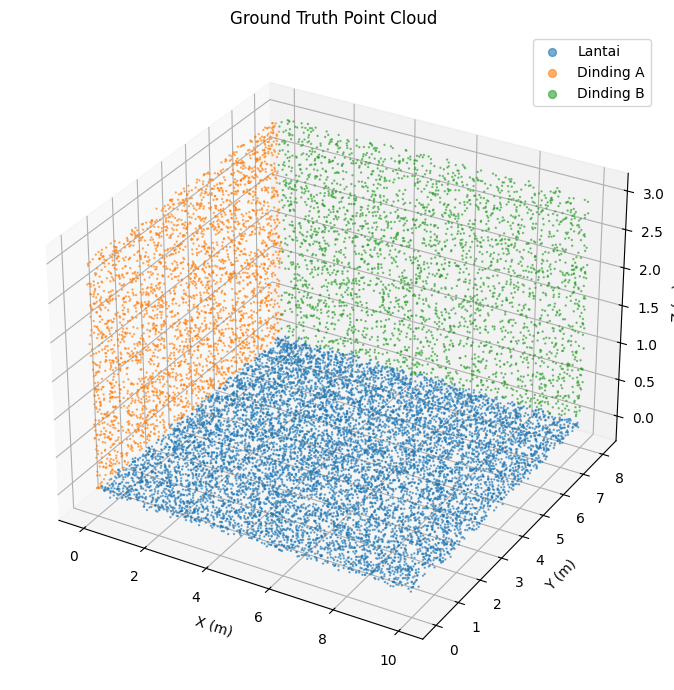

In [4]:
# Visualisasi Ground Truth
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for label in [0, 1, 2]:
    mask = labels_gt == label
    ax.scatter(
        points[mask, 0], points[mask, 1], points[mask, 2],
        c=LABEL_COLORS[label], s=0.5, label=LABEL_NAMES[label], alpha=0.6
    )

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Ground Truth Point Cloud')
ax.legend(markerscale=8)
plt.tight_layout()
plt.show()

## 2. Metode 1: RANSAC Iteratif

**Model bidang**: ax + by + cz + d = 0

Algoritma per iterasi:
1. Pilih 3 titik secara acak → bentuk bidang
2. Hitung jarak semua titik ke bidang → hitung **inlier** (jarak < threshold)
3. Simpan model dengan inlier terbanyak

Dijalankan **3 kali** secara iteratif: setiap bidang yang ditemukan dihapus dari point cloud sebelum mencari bidang berikutnya.

In [ ]:
def ransac_plane(pts, n_iter=1000, threshold=0.05):
    """Fit satu bidang ax+by+cz+d=0 ke pts, kembalikan (plane, inlier_indices)."""
    best_inliers = np.array([], dtype=int)
    best_plane = None
    n = len(pts)

    for _ in range(n_iter):
        idx = np.random.choice(n, 3, replace=False)
        p1, p2, p3 = pts[idx]

        normal = np.cross(p2 - p1, p3 - p1)
        norm = np.linalg.norm(normal)
        if norm < 1e-10:
            continue
        normal = normal / norm
        d = -np.dot(normal, p1)

        distances = np.abs(pts @ normal + d)
        inliers = np.where(distances < threshold)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_plane = (*normal, d)

    return best_plane, best_inliers


def assign_label(plane):
    """Tentukan label (0=lantai, 1=dinding A, 2=dinding B) dari normal bidang."""
    a, b, c, _ = plane
    dominant = np.argmax(np.abs([a, b, c]))
    return int(dominant == 2) * 0 + int(dominant == 0) * 1 + int(dominant == 1) * 2


# --- Jalankan RANSAC Iteratif ---
t0 = time.perf_counter()

labels_ransac = np.full(len(points), -1, dtype=int)
remaining = np.arange(len(points))

for _ in range(3):
    plane, local_inliers = ransac_plane(points[remaining], n_iter=1000, threshold=0.05)
    global_inliers = remaining[local_inliers]
    label = assign_label(plane)
    labels_ransac[global_inliers] = label
    remaining = np.setdiff1d(remaining, global_inliers)

t_ransac = time.perf_counter() - t0

print(f"Waktu RANSAC    : {t_ransac:.3f} detik")
print(f"Unclassified    : {np.sum(labels_ransac == -1)}")
for lbl, name in LABEL_NAMES.items():
    if lbl == -1: continue
    print(f"  {name:12s}: {np.sum(labels_ransac == lbl)} titik")

In [ ]:
# Visualisasi hasil RANSAC
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for label in [0, 1, 2, -1]:
    mask = labels_ransac == label
    if not np.any(mask):
        continue
    ax.scatter(
        points[mask, 0], points[mask, 1], points[mask, 2],
        c=LABEL_COLORS[label], s=0.5, label=LABEL_NAMES[label], alpha=0.6
    )

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Hasil Segmentasi RANSAC')
ax.legend(markerscale=8)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluasi RANSAC
mask_valid = labels_ransac != -1
y_true = labels_gt[mask_valid]
y_pred = labels_ransac[mask_valid]

print("=== Evaluasi RANSAC ===")
print(f"Akurasi  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print()
print(classification_report(y_true, y_pred, target_names=[LABEL_NAMES[i] for i in range(3)], zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(cm, display_labels=[LABEL_NAMES[i] for i in range(3)])
disp.plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — RANSAC')
plt.tight_layout()
plt.show()